# Expected Free energy minimization for mobile robot navigation

### Joost Leliveld, last update: 06-02-2026  
Heavily inspired from Wouter Kouw

### Usecase:

A robot that moves according to the constant-velocity model is observed by an external static camera. The camera provides image measurements (pixel location) to help the robot navigate from point A to point B. The ground is assumed to be planar and the camera intrinsics as well as the homography known. This makes the observation model nonlinear and the effects of this will be studied for different control types. 

### Dynamics (differential-drive / unicycle model)

Consider a robot that moves according to the unicycle model with linear and angular velocity inputs:

$$z_k = \begin{bmatrix} x_k \\ y_k \\ \theta_k \end{bmatrix},\qquad
 u_k = \begin{bmatrix} v_k \\ \omega_k \end{bmatrix}.$$

The discrete-time dynamics are

$$
\begin{aligned}
 x_k &= x_{k-1} + v_k\,\Delta t\,\cos(\theta_{k-1}) \\
 y_k &= y_{k-1} + v_k\,\Delta t\,\sin(\theta_{k-1}) \\
 \theta_k &= \theta_{k-1} + \omega_k\,\Delta t
\end{aligned}
\qquad +\; q_k\,.
$$


Process noise is white, $q_k \sim \mathcal{N}(0,Q)$.

For the notebook we use a simple diagonal model in $[x,y,\theta]$:

$$
Q =
\begin{bmatrix}
\sigma_x^2 & 0 & 0 \\
0 & \sigma_y^2 & 0 \\
0 & 0 & \sigma_\theta^2
\end{bmatrix}\, .
$$

These values are *placeholders* and should be replaced with estimates from simulation or real data.


### Observations: external oblique camera (pixels)

A static external camera observes the robot in the image plane. The measurement is the pixel location:

$$o_k \triangleq \begin{bmatrix} u_k^{\mathrm{pix}} \\ v_k^{\mathrm{pix}} \end{bmatrix} \in \mathbb{R}^2.$$

The camera measurement is generated by a nonlinear projective mapping:

$$o_k = g(z_k) + r_k,\qquad r_k \sim \mathcal{N}(0,R),$$

where $g(z_k)$ is defined as the composition of (i) ground-plane embedding into 3D, (ii) rigid transform into the camera frame, and (iii) perspective projection to pixels. Since the camera observes position on the ground plane, the observation model depends only on the position components. 

#### Projective mapping (state $\rightarrow$ pixels)
https://docs.opencv.org/4.x/d9/dab/tutorial_homography.html 
1) **Embed the ground-plane point into 3D (world frame).**  
Assuming a planar ground ($Z=0$):

$$P_w(p_k) \triangleq \begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix}
=
\begin{bmatrix} x_k \\ y_k \\ 0 \\ 1 \end{bmatrix}.$$

2) **Transform world coordinates to camera coordinates.**  
Let $(R_{cw},t_{cw})$ be the camera extrinsics (world-to-camera):

$$\begin{bmatrix} X_c \\ Y_c \\ Z_c \end{bmatrix}
=
R_{cw}\begin{bmatrix} X \\ Y \\ Z \end{bmatrix} + t_{cw}.$$

3) **Perspective division (nonlinearity).**  
Normalized image coordinates are obtained by:

$$x_n = \frac{X_c}{Z_c},\qquad y_n = \frac{Y_c}{Z_c}.$$

4) **Intrinsics map normalized coordinates to pixels.**  
With camera intrinsics $(f_x,f_y,c_x,c_y)$:

$$u_k^{\mathrm{pix}} = f_x x_n + c_x,\qquad
v_k^{\mathrm{pix}} = f_y y_n + c_y.$$

Putting these steps together defines $g(z_k)$:
$$g(z_k) \triangleq 
\begin{bmatrix}
f_x \frac{X_c(p_k)}{Z_c(p_k)} + c_x \\
f_y \frac{Y_c(p_k)}{Z_c(p_k)} + c_y
\end{bmatrix},
\qquad p_k = (x_k, y_k).$$

The mapping is nonlinear because of the perspective division by $Z_c(p_k)$, which induces state-dependent sensitivity of pixels to changes in ground-plane position.


### Probabilistic model

We use a probabilistic state-space model with nonlinear unicycle dynamics and a nonlinear camera observation model:

$$\begin{align}
p(z_0) &= \mathcal{N}(z_0 \mid m_0, S_0) \\
p(z_k \mid z_{k-1}, u_k) &= \mathcal{N}(z_k \mid f(z_{k-1}, u_k), Q) \\
p(o_k \mid z_k) &= \mathcal{N}(o_k \mid g(z_k), R)\, .
\end{align}$$

Here, $z_k \in \mathbb{R}^3$ is the ground-plane unicycle state and $o_k$ is the external camera measurement in the image plane.


### Gaussian approximation to likelihood

Because $g(\cdot)$ is nonlinear, the likelihood $p(o_k \mid z_k)$ is generally non-Gaussian as a function of $z_k$:

Using the projective observation model,

$$
g(z_k)
=
\begin{bmatrix}
f_x \dfrac{X_c(p_k)}{Z_c(p_k)} + c_x \\
f_y \dfrac{Y_c(p_k)}{Z_c(p_k)} + c_y
\end{bmatrix},
$$

the likelihood can be written (up to a normalization constant) as

$$
p(o_k \mid z_k)
=
\frac{1}{\sqrt{(2\pi)^2 \det R}}
\exp\!\Big(-\tfrac12 (o_k-g(z_k))^\top R^{-1}(o_k-g(z_k))\Big).
$$

$$
\log p(o_k \mid z_k)
=
-\tfrac12 \big(o_k - g(z_k)\big)^\top R^{-1} \big(o_k - g(z_k)\big).
$$

Since the term is not just a power of $o$ or $z$, the likelihood is non-Gaussian. We approximate the joint $(z_k, o_k)$ as a Gaussian:

$$p(o_k, z_k) \approx \mathcal{N}\!\left(
\begin{bmatrix} z_k \\ o_k \end{bmatrix}
\Bigg|\,
\begin{bmatrix} m_k \\ \mu_k \end{bmatrix},
\begin{bmatrix} S_k & \Gamma_k \\ \Gamma_k^{\top} & \Sigma_k \end{bmatrix}
\right)\, .$$

Here:
- $m_k, S_k$ are the predicted state mean and covariance,
- $\mu_k, \Sigma_k$ are the predicted observation mean and covariance,
- $\Gamma_k$ is the state--observation cross-covariance.

Because this joint is Gaussian, conditioning yields an approximate Gaussian likelihood:

$$\begin{align}
p(o_k \mid z_k)
&\approx \mathcal{N}\!\left(
o_k \,\Big|\,
\mu_k + \Gamma_k^{\top} S_k^{-1}(z_k - m_k),
\ \Sigma_k - \Gamma_k^{\top} S_k^{-1}\Gamma_k
\right)\, .
\end{align}$$

The parameters $(\mu_k, \Sigma_k, \Gamma_k)$ are obtained by a Gaussian approximation method:
first-order Taylor (ET1/EFE1), second-order Taylor (ET2/EFE2), or sigma-point (UT) approximation.


## Posterior predictive

The posterior predictive distribution of the observation is obtained by marginalizing
over the latent state:

$$
\begin{align}
p(o_k \mid o_{1:k-1})
&= \int p(o_k \mid z_k)\, p(z_k \mid o_{1:k-1}) \, dz_k \tag{1}\\
&= \int \mathcal N\!\left(
\begin{bmatrix} z_k \\ o_k \end{bmatrix}
\Bigg|\,
\begin{bmatrix} m_k \\ \mu_k \end{bmatrix},
\begin{bmatrix}
S_k & \Gamma_k \\
\Gamma_k^\top & \Sigma_k
\end{bmatrix}
\right) dz_k \tag{2}\\
&= \mathcal N(o_k \mid \mu_k, \Sigma_k). \tag{3}
\end{align}
$$

That is, marginalizing a joint Gaussian yields a Gaussian predictive distribution
with mean $\mu_k$ and covariance $\Sigma_k$.


## Planning and control

### Expected Free Energy (EFE) objective

The Expected Free Energy objective for a single time step is given by

$$
\mathcal J_k(u_t)
=
\mathcal C
+
\frac{1}{2}\,\mathrm{tr}\!\left(S_*^{-1}(\Sigma_t + \Sigma_\star)\right)
+
\frac{1}{2}\,\ln
\frac{\left| \Sigma_t - \Gamma_t^\top S_t^{-1} \Gamma_t \right|}
{\left| \Sigma_t \right|}. \tag{1}
$$

The first term encodes the expected risk, while the log-determinant term captures
expected ambiguity through the conditional observation covariance.

### Horizon-based control optimization

For a planning horizon of $T$ steps, the optimal control sequence is obtained as

$$
\begin{align}
\hat u
&= \arg\max_{u \in \mathcal U} q^\star(u) \tag{1}\\
&= \arg\min_{u \in \mathcal U}
\sum_{t=1}^{T} \mathcal J_t(u_t)
- \ln p(u_t). \tag{2}
\end{align}
$$


In [ ]:
from pathlib import Path
import sys

CWD = Path.cwd()
ROOT = CWD if (CWD / "scripts").exists() else CWD.parent
sys.path.insert(0, str(ROOT / "scripts"))
ANIM_DIR = ROOT / "scripts" / "animations"
ANIM_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = ROOT / "scripts" / "figures"
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.optimize import minimize
from scipy.stats import multivariate_normal
from tqdm import tqdm

from robots import UnicycleBot, update_unicycle
from botnav_efe_helpers import (
    PlanarCamera,
    UnicycleEFEAgent,
    predict_unicycle,
    correct,
    evidence,
    planned_trajectory_unicycle,
)
from botnav_efe_jax import bind_unicycle_agent_jax, make_homography_g_jax, make_unicycle_valgrad_fn


In [15]:
# Matplotlib settings
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['lines.markersize'] = 3

def plot_cov_ellipse(ax, mean, cov, n_std=1, color='blue', alpha=0.3, linewidth=0):
    eigenvals, eigenvecs = np.linalg.eigh(cov)
    order = eigenvals.argsort()[::-1]
    eigenvals, eigenvecs = eigenvals[order], eigenvecs[:, order]

    angle = np.degrees(np.arctan2(*eigenvecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvals)

    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  color=color, alpha=alpha, linewidth=linewidth)
    ax.add_patch(ell)


In [ ]:
# =========================
# EXPERIMENT SETUP (simple)
# =========================

# --- Time ---
Δt = 0.2
len_trial = 50
len_horizon = 5

# --- Camera ---
camera = PlanarCamera(
    cam_pos=np.array([-3.0, -3.0, 3.0]),
    look_at=np.array([5.0, 5.0, 0.0]),
    img_width=1920,
    img_height=1080,
    fov_h_rad=np.deg2rad(120.0),
)

def g(x):
    return camera.g(x)

# --- Noise (explicit, tweak later) ---
sigma_process_xy = 0.05
sigma_process_theta = np.deg2rad(2.0)
Q = np.diag([sigma_process_xy**2, sigma_process_xy**2, sigma_process_theta**2])

sigma_pix = 1.0
R = np.diag([sigma_pix**2, sigma_pix**2])

# --- Control limits (TurtleBot-style defaults) ---
v_lims = (-0.22, 1)
w_lims = (-2.84, 2.84)
η = 0.0

# --- Start / goal (manual) ---
start_xy = np.array([0.0, 0.0])
goal_xy  = np.array([1.0, 1.0])

theta_0 = np.arctan2(goal_xy[1] - start_xy[1], goal_xy[0] - start_xy[0])
z_0 = np.array([start_xy[0], start_xy[1], theta_0])
z_star = np.array([goal_xy[0],  goal_xy[1],  theta_0])

# --- Goal observation ---
goal_sigma_pix = 5.0
goal_obs = g(z_star)
goal = (goal_obs, goal_sigma_pix**2 * np.eye(goal_obs.size))

# --- Initial belief ---
sigma_init_xy = 0.5
sigma_init_theta = np.deg2rad(10.0)
m_0 = z_0.copy()
S_0 = np.diag([sigma_init_xy**2, sigma_init_xy**2, sigma_init_theta**2])

# --- Robot + Agent ---
fbot = UnicycleBot(g, Q=Q, R=R, dt=Δt, control_lims=(v_lims, w_lims))
agent = UnicycleEFEAgent(goal, g, Q=Q, R=R, eta=η, dt=Δt, time_horizon=len_horizon)

# --- Output folders ---
FIG_DIR = ROOT / "scripts" / "figures"
ANIM_DIR = ROOT / "scripts" / "animations"
FIG_DIR.mkdir(parents=True, exist_ok=True)
ANIM_DIR.mkdir(parents=True, exist_ok=True)

print("Start:", start_xy, "theta=", theta_0)
print("Goal :", goal_xy,  "theta=", theta_0)


Start: [0. 0.] theta= 0.7853981633974483
Goal : [1. 1.] theta= 0.7853981633974483


In [39]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

params_j = bind_unicycle_agent_jax(agent)
g_jax = make_homography_g_jax(camera.H)


In [40]:
def animate_run(z_sim, z_est, z_pln, label, filename, xl, yl):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(xl)
    ax.set_ylim(yl)
    ax.set_aspect('equal')
    ax.set_xlabel("position x")
    ax.set_ylabel("position y")

    def animate_frame(k):
        ax.clear()
        ax.set_xlim(xl)
        ax.set_ylim(yl)
        ax.set_aspect('equal')
        ax.set_title(f"{label}: {k+1}/{len_trial}")
        ax.set_xlabel("position x")
        ax.set_ylabel("position y")

        ax.scatter([z_0[0]], [z_0[1]], color="blue", label="start", s=25)
        ax.scatter([z_star[0]], [z_star[1]], color="red", label="goal state", s=25)

        ax.plot(z_sim[0, 1:k+1], z_sim[1, 1:k+1], c="blue", label="true", alpha=0.5)
        ax.plot(z_est[0][0, 1:k+1], z_est[0][1, 1:k+1], c="purple", label="inferred", alpha=0.5)
        plot_cov_ellipse(ax, z_est[0][0:2, k], z_est[1][0:2, 0:2, k],
                         n_std=1, color="purple", alpha=0.3, linewidth=0)

        ax.plot(z_pln[0][k, 0, :], z_pln[0][k, 1, :], c="orange", label="planned")
        for j in range(len_horizon):
            plot_cov_ellipse(ax, z_pln[0][k, 0:2, j], z_pln[1][k, 0:2, 0:2, j],
                             n_std=1, color="orange", alpha=0.3, linewidth=0)

        if k == 2:
            ax.legend(loc='upper left')

    anim = FuncAnimation(fig, animate_frame, frames=range(2, len_trial), interval=1000, repeat=False)
    anim.save(str(ANIM_DIR / filename), writer=PillowWriter(fps=1))
    plt.close()


In [41]:
def plot_run(z_sim, z_est, label, xl=None, yl=None, save_path=None):
    # Recompute camera footprint in world
    W, H = camera.img_width, camera.img_height
    corner_pixels = [(0, 0), (W, 0), (W, H), (0, H), (0, 0)]
    corner_world = []
    for u, v in corner_pixels:
        x, y = camera.pixel_to_world(u, v)
        if np.isfinite(x) and np.isfinite(y):
            corner_world.append([x, y])
    corner_world = np.array(corner_world)

    fig, ax = plt.subplots(figsize=(8, 5))

    # Auto-limits include both trajectory + footprint
    if xl is None or yl is None:
        xs = [z_sim[0, :], z_est[0][0, :], np.array([z_star[0]])]
        ys = [z_sim[1, :], z_est[0][1, :], np.array([z_star[1]])]
        if corner_world.size > 0:
            xs.append(corner_world[:, 0])
            ys.append(corner_world[:, 1])
        xs = np.concatenate(xs)
        ys = np.concatenate(ys)
        margin = 0.2
        xl = [xs.min() - margin, xs.max() + margin]
        yl = [ys.min() - margin, ys.max() + margin]

    ax.set_xlim(xl)
    ax.set_ylim(yl)
    ax.set_xlabel("position x")
    ax.set_ylabel("position y")
    ax.set_aspect("equal")

    ax.scatter([z_sim[0, 0]], [z_sim[1, 0]], color="green", marker="D", label="start", s=64)
    ax.scatter([z_star[0]], [z_star[1]], color="green", label="goal", s=64)

    ax.plot(z_sim[0, :], z_sim[1, :], c="blue", label="true")
    ax.plot(z_est[0][0, :], z_est[0][1, :], c="purple", label="inferred")

    for j in range(len_trial):
        plot_cov_ellipse(ax, z_est[0][0:2, j], z_est[1][0:2, 0:2, j],
                         n_std=1, color="purple", alpha=0.1, linewidth=0)

    # Plot footprint only if valid polygon
    if corner_world.shape[0] >= 3:
        ax.plot(corner_world[:, 0], corner_world[:, 1], "k--", linewidth=1.0, label="camera footprint")

    ax.set_title(label)
    ax.legend(loc="upper left")
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


## Model: EFE(ET2)

In [42]:
# assumes params_j and g_jax already defined in the JAX setup cell
valgrad = make_unicycle_valgrad_fn(params_j, g_jax, approx="ET2", add_ambiguity=True, mode="fwd")

z_est = (np.zeros((3, len_trial)), np.zeros((3, 3, len_trial)))
z_pln = (np.zeros((len_trial, 3, len_horizon)), np.zeros((len_trial, 3, 3, len_horizon)))
y_pln = (np.zeros((len_trial, agent.Dy, len_horizon)), np.zeros((len_trial, agent.Dy, agent.Dy, len_horizon)))
z_sim = np.zeros((3, len_trial))
y_sim = np.zeros((agent.Dy, len_trial))
u_sim = np.zeros((2, len_trial))
F_EFE2 = np.zeros(len_trial)
J_EFE2 = np.zeros(len_trial)

z_est[0][:, 0] = m_0
z_est[1][:, :, 0] = S_0

# Initial state
z_sim[:, 0] = z_0

# Start recursion
m_kmin1 = m_0
S_kmin1 = S_0

policy = np.zeros((2, len_horizon))

for k in tqdm(range(1, len_trial), desc="EFE2 Experiment"):

    # Interact with environment
    y_sim[:, k], z_sim[:, k] = update_unicycle(fbot, z_sim[:, k-1], u_sim[:, k-1])

    # State estimation
    m_k_pred, S_k_pred = predict_unicycle(agent, m_kmin1, S_kmin1, u_sim[:, k-1])
    m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET2")

    # Compute model evidence
    F_EFE2[k] = evidence(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET2")
    J_EFE2[k] = -multivariate_normal.logpdf(y_sim[:, k], goal[0], goal[1])

    # Store state estimates
    z_est[0][:, k] = m_k
    z_est[1][:, :, k] = S_k

    # Planning
    bounds = [v_lims, w_lims] * len_horizon

    def f(u):
        val, _ = valgrad(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.array(val)

    def grad_u(u):
        _, grad = valgrad(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.array(grad)

    result = minimize(
        f,
        np.zeros(2 * len_horizon),  # cold start like Julia
        jac=grad_u,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 200, 'maxfun': 2000, 'ftol': 1e-6}
    )

    # Extract minimizing control
    policy = result.x.reshape((2, len_horizon))
    u_sim[:, k] = policy[:, 0]

    # Planning
    planned_states, planned_obs = planned_trajectory_unicycle(agent, policy, (m_k, S_k), approx="ET2")
    z_pln[0][k, :, :] = planned_states[0]
    z_pln[1][k, :, :, :] = planned_states[1]
    y_pln[0][k, :, :] = planned_obs[0]
    y_pln[1][k, :, :, :] = planned_obs[1]

    # Update recursion
    m_kmin1 = m_k
    S_kmin1 = S_k


EFE2 Experiment: 100%|██████████| 99/99 [00:18<00:00,  5.26it/s]


IndexError: list index out of range

Error in callback <function _draw_all_if_interactive at 0x7cf84199dcf0> (for post_execute), with arguments args (),kwargs {}:


NameError: name 'plot_cov_ellipse' is not defined

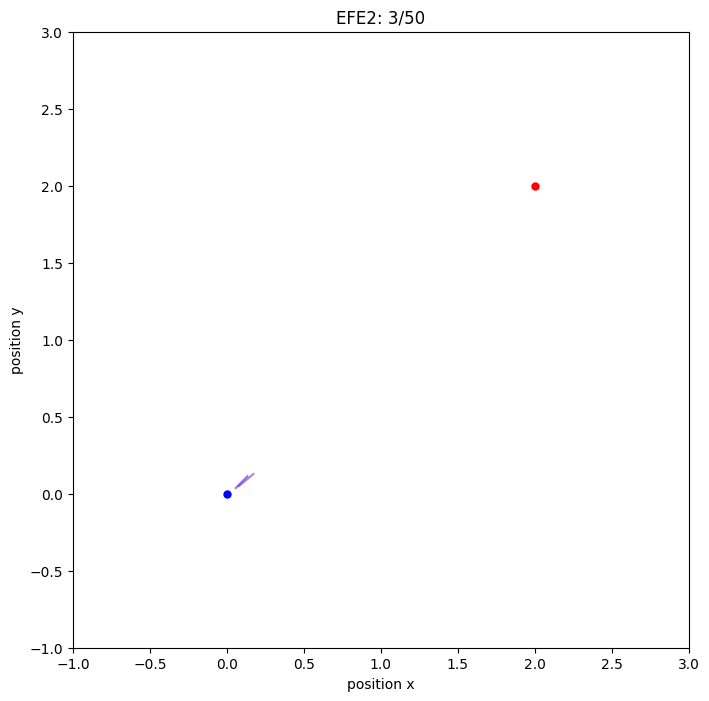

In [12]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]

animate_run(
    z_sim=z_sim,
    z_est=z_est,
    z_pln=z_pln,
    label="EFE2",
    filename="bev2image-experiment-EFE2-path.gif",
    xl=xl,
    yl=yl,
)


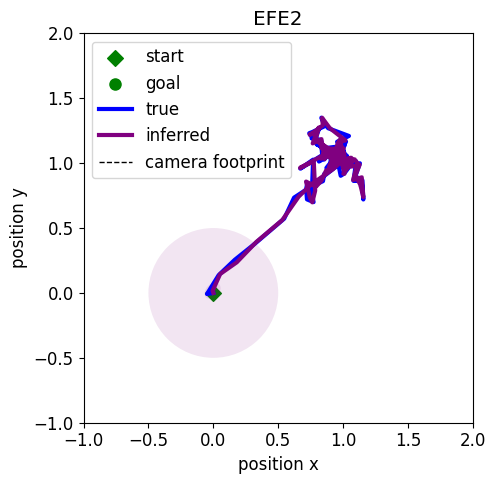

In [43]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]
plot_run(z_sim, z_est, label="EFE2", xl=xl, yl=yl, save_path=FIG_DIR / "bev2image-experiment-EFE2-zoom.png")



In [44]:
# JAX val+grad for EFE1 (forward-mode)
valgrad_efe1 = make_unicycle_valgrad_fn(params_j, g_jax, approx="ET1", add_ambiguity=True, mode="fwd")

# Preallocate
z_est = (np.zeros((3, len_trial)), np.zeros((3, 3, len_trial)))
z_pln = (np.zeros((len_trial, 3, len_horizon)), np.zeros((len_trial, 3, 3, len_horizon)))
y_pln = (np.zeros((len_trial, agent.Dy, len_horizon)), np.zeros((len_trial, agent.Dy, agent.Dy, len_horizon)))
z_sim = np.zeros((3, len_trial))
y_sim = np.zeros((agent.Dy, len_trial))
u_sim = np.zeros((2, len_trial))
F_EFE1 = np.zeros(len_trial)
J_EFE1 = np.zeros(len_trial)
z_est[0][:, 0] = m_0
z_est[1][:, :, 0] = S_0

# Initial state
z_sim[:, 0] = z_0

# Start recursion
m_kmin1 = m_0
S_kmin1 = S_0

policy = np.zeros((2, len_horizon))

for k in tqdm(range(1, len_trial), desc="EFE1 Experiment"):

    # Interact with environment
    y_sim[:, k], z_sim[:, k] = update_unicycle(fbot, z_sim[:, k-1], u_sim[:, k-1])

    # State estimation
    m_k_pred, S_k_pred = predict_unicycle(agent, m_kmin1, S_kmin1, u_sim[:, k-1])
    m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET1")

    # Compute model evidence
    F_EFE1[k] = evidence(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET1")
    J_EFE1[k] = -multivariate_normal.logpdf(y_sim[:, k], goal[0], goal[1])

    # Store state estimates
    z_est[0][:, k] = m_k
    z_est[1][:, :, k] = S_k

    # Planning
    bounds = [v_lims, w_lims] * len_horizon

    def f(u):
        val, _ = valgrad_efe1(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.array(val)

    def grad_u(u):
        _, grad = valgrad_efe1(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.array(grad)

    result = minimize(
        f,
        np.zeros(2 * len_horizon),  # cold start like Julia
        jac=grad_u,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 200, 'maxfun': 2000, 'ftol': 1e-6}
    )

    # Extract minimizing control
    policy = result.x.reshape((2, len_horizon))
    u_sim[:, k] = policy[:, 0]

    # Planning
    planned_states, planned_obs = planned_trajectory_unicycle(agent, policy, (m_k, S_k), approx="ET1")
    z_pln[0][k, :, :] = planned_states[0]
    z_pln[1][k, :, :, :] = planned_states[1]
    y_pln[0][k, :, :] = planned_obs[0]
    y_pln[1][k, :, :, :] = planned_obs[1]

    # Update recursion
    m_kmin1 = m_k
    S_kmin1 = S_k


EFE1 Experiment: 100%|██████████| 99/99 [00:17<00:00,  5.80it/s]


In [230]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]

animate_run(
    z_sim=z_sim,
    z_est=z_est,
    z_pln=z_pln,
    label="EFE1",
    filename="bev2image-experiment-EFE1-path.gif",
    xl=xl,
    yl=yl,
)


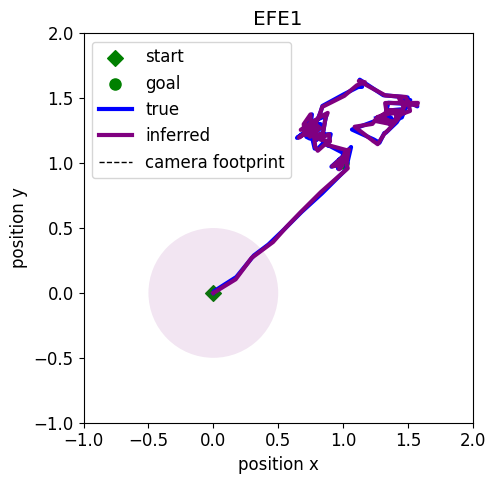

In [45]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]
plot_run(z_sim, z_est, label="EFE1", xl=xl, yl=yl, save_path=FIG_DIR / "bev2image-experiment-EFE1-zoom.png")



In [46]:
# JAX val+grad for EFER (ET2, no ambiguity)
valgrad_efer = make_unicycle_valgrad_fn(params_j, g_jax, approx="ET2", add_ambiguity=False, mode="fwd")

# Preallocate
z_est = (np.zeros((3, len_trial)), np.zeros((3, 3, len_trial)))
z_pln = (np.zeros((len_trial, 3, len_horizon)), np.zeros((len_trial, 3, 3, len_horizon)))
y_pln = (np.zeros((len_trial, agent.Dy, len_horizon)), np.zeros((len_trial, agent.Dy, agent.Dy, len_horizon)))
z_sim = np.zeros((3, len_trial))
y_sim = np.zeros((agent.Dy, len_trial))
u_sim = np.zeros((2, len_trial))
F_EFER = np.zeros(len_trial)
J_EFER = np.zeros(len_trial)

# Initialize first estimate (avoids line to origin)
z_est[0][:, 0] = m_0
z_est[1][:, :, 0] = S_0

# Initial state
z_sim[:, 0] = z_0

# Start recursion
m_kmin1 = m_0
S_kmin1 = S_0

policy = np.zeros((2, len_horizon))

for k in tqdm(range(1, len_trial), desc="EFER Experiment"):

    # Interact with environment
    y_sim[:, k], z_sim[:, k] = update_unicycle(fbot, z_sim[:, k-1], u_sim[:, k-1])

    # State estimation
    m_k_pred, S_k_pred = predict_unicycle(agent, m_kmin1, S_kmin1, u_sim[:, k-1])
    m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx="ET2")

    # Compute model evidence (Julia uses corrected + ET2)
    F_EFER[k] = evidence(agent, y_sim[:, k], m_k, S_k, approx="ET2")
    J_EFER[k] = -multivariate_normal.logpdf(y_sim[:, k], goal[0], goal[1])

    # Store state estimates
    z_est[0][:, k] = m_k
    z_est[1][:, :, k] = S_k

    # Planning
    bounds = [v_lims, w_lims] * len_horizon

    def f(u):
        val, _ = valgrad_efer(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.array(val)

    def grad_u(u):
        _, grad = valgrad_efer(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
        return np.array(grad)

    result = minimize(
        f,
        np.zeros(2 * len_horizon),  # cold start like Julia
        jac=grad_u,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 200, 'maxfun': 2000, 'ftol': 1e-6}
    )

    # Extract minimizing control
    policy = result.x.reshape((2, len_horizon))
    u_sim[:, k] = policy[:, 0]

    # Planning
    planned_states, planned_obs = planned_trajectory_unicycle(agent, policy, (m_k, S_k), approx="ET2")
    z_pln[0][k, :, :] = planned_states[0]
    z_pln[1][k, :, :, :] = planned_states[1]
    y_pln[0][k, :, :] = planned_obs[0]
    y_pln[1][k, :, :, :] = planned_obs[1]

    # Update recursion
    m_kmin1 = m_k
    S_kmin1 = S_k


EFER Experiment: 100%|██████████| 99/99 [00:18<00:00,  5.38it/s]


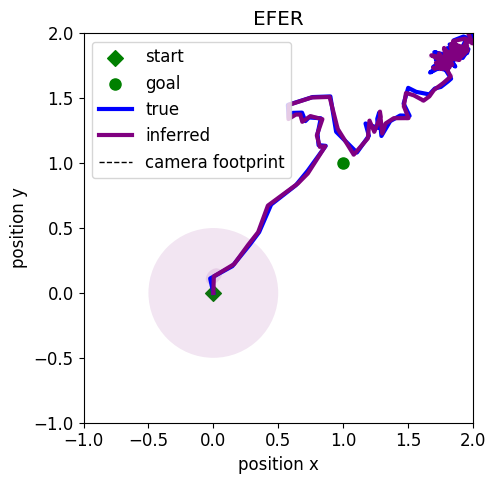

In [47]:
# tight zoom around start/goal
pad = 1.0
xl = [min(z_0[0], z_star[0]) - pad, max(z_0[0], z_star[0]) + pad]
yl = [min(z_0[1], z_star[1]) - pad, max(z_0[1], z_star[1]) + pad]
plot_run(z_sim, z_est, label="EFER", xl=xl, yl=yl, save_path=FIG_DIR / "bev2image-experiment-EFER-zoom.png")


In [48]:
tF_EFE2 = np.sum(F_EFE2)
tF_EFE1 = np.sum(F_EFE1)
tF_EFER = np.sum(F_EFER)

print(f"F EFE2 = {tF_EFE2}")
print(f"F EFE1 = {tF_EFE1}")
print(f"F EFER = {tF_EFER}")


F EFE2 = 536.591170963029
F EFE1 = 528.0878245845867
F EFER = 255.65403751004987


In [49]:
tJ_EFE2 = np.sum(J_EFE2)
tJ_EFE1 = np.sum(J_EFE1)
tJ_EFER = np.sum(J_EFER)

print(f"Total goal prior -log-likelihood EFE2 = {tJ_EFE2}")
print(f"Total goal prior -log-likelihood EFE1 = {tJ_EFE1}")
print(f"Total goal prior -log-likelihood EFER = {tJ_EFER}")

Total goal prior -log-likelihood EFE2 = 1208.516321694806
Total goal prior -log-likelihood EFE1 = 2001.276711270082
Total goal prior -log-likelihood EFER = 3774.9375550238615


In [50]:
perf_EFE2 = np.sum(F_EFE2) + np.sum(J_EFE2)
perf_EFE1 = np.sum(F_EFE1) + np.sum(J_EFE1)
perf_EFER = np.sum(F_EFER) + np.sum(J_EFER)

print(f"Performance EFE2 = {perf_EFE2}")
print(f"Performance EFE1 = {perf_EFE1}")
print(f"Performance EFER = {perf_EFER}")

Performance EFE2 = 1745.1074926578349
Performance EFE1 = 2529.3645358546687
Performance EFER = 4030.5915925339114


In [ ]:
# --- Monte Carlo run + mean/std plots (EFE1, EFER, EFE2) ---

n_runs = 50
seed0 = 0

def run_mc(approx, add_ambiguity, n_runs=50, seed0=0):
    true_runs = np.zeros((n_runs, len_trial, 2))
    est_runs = np.zeros((n_runs, len_trial, 2))

    valgrad = make_unicycle_valgrad_fn(params_j, g_jax, approx=approx, add_ambiguity=add_ambiguity, mode="fwd")

    for r in range(n_runs):
        np.random.seed(seed0 + r)

        z_sim = np.zeros((3, len_trial))
        y_sim = np.zeros((agent.Dy, len_trial))
        u_sim = np.zeros((2, len_trial))
        z_est = (np.zeros((3, len_trial)), np.zeros((3, 3, len_trial)))

        z_sim[:, 0] = z_0
        z_est[0][:, 0] = m_0
        z_est[1][:, :, 0] = S_0

        m_kmin1 = m_0
        S_kmin1 = S_0
        policy = np.zeros((2, len_horizon))

        for k in range(1, len_trial):
            # Environment
            y_sim[:, k], z_sim[:, k] = update_unicycle(fbot, z_sim[:, k-1], u_sim[:, k-1])

            # State estimation
            m_k_pred, S_k_pred = predict_unicycle(agent, m_kmin1, S_kmin1, u_sim[:, k-1])
            m_k, S_k = correct(agent, y_sim[:, k], m_k_pred, S_k_pred, approx=approx)

            # Store estimate
            z_est[0][:, k] = m_k
            z_est[1][:, :, k] = S_k

            # Planning
            bounds = [v_lims, w_lims] * len_horizon

            def f(u):
                val, _ = valgrad(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
                return np.array(val)

            def grad_u(u):
                _, grad = valgrad(jnp.array(u), jnp.array(m_k), jnp.array(S_k))
                return np.array(grad)

            result = minimize(
                f,
                np.zeros(2 * len_horizon),  # cold start
                jac=grad_u,
                method='L-BFGS-B',
                bounds=bounds,
                options={'maxiter': 200, 'maxfun': 2000, 'ftol': 1e-6}
            )

            policy = result.x.reshape((2, len_horizon))
            u_sim[:, k] = policy[:, 0]

            m_kmin1 = m_k
            S_kmin1 = S_k

        true_runs[r] = z_sim[:2].T
        est_runs[r] = z_est[0][:2].T

    return true_runs, est_runs


def plot_ribbon(ax, x_mean, y_mean, x_std, y_std, color, alpha=0.2):
    # ribbon in normal direction
    dx = np.gradient(x_mean)
    dy = np.gradient(y_mean)
    norm = np.sqrt(dx**2 + dy**2) + 1e-9
    nx = -dy / norm
    ny = dx / norm
    r = np.sqrt(x_std**2 + y_std**2)

    x_upper = x_mean + nx * r
    y_upper = y_mean + ny * r
    x_lower = x_mean - nx * r
    y_lower = y_mean - ny * r

    ax.fill(
        np.concatenate([x_upper, x_lower[::-1]]),
        np.concatenate([y_upper, y_lower[::-1]]),
        color=color, alpha=alpha, linewidth=0
    )


methods = [
    ("EFE1", "ET1", True),
    ("EFER", "ET2", False),
    ("EFE2", "ET2", True),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)

for ax, (title, approx, add_amb) in zip(axes, methods):
    true_runs, est_runs = run_mc(approx, add_amb, n_runs=n_runs, seed0=seed0)

    # mean + std (std of mean)
    true_mean = true_runs.mean(axis=0)
    true_std = true_runs.std(axis=0, ddof=1) / np.sqrt(n_runs)

    est_mean = est_runs.mean(axis=0)
    est_std = est_runs.std(axis=0, ddof=1) / np.sqrt(n_runs)

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    # plot ribbons
    plot_ribbon(ax, true_mean[:, 0], true_mean[:, 1], true_std[:, 0], true_std[:, 1],
                color="blue", alpha=0.25)
    plot_ribbon(ax, est_mean[:, 0], est_mean[:, 1], est_std[:, 0], est_std[:, 1],
                color="purple", alpha=0.20)

    # plot mean trajectories
    ax.plot(true_mean[:, 0], true_mean[:, 1], color="blue", label="system")
    ax.plot(est_mean[:, 0], est_mean[:, 1], color="purple", label="estimate")

    ax.scatter([z_0[0]], [z_0[1]], color="green", marker="D", s=50, label="start")
    ax.scatter([z_star[0]], [z_star[1]], color="red", s=50, label="goal")

axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()
